# (QLora) Fine-tuning Deepseek to convert from C to assembly with documentation


## Imports

In [ ]:
!pip install optimum #library that speeds up training and is a dependency required for advanced optimization features like BetterTransformer (which speeds up inference later).
!pip install bitsandbytes #this is the library used for quantization of the model weights. It contains the algorithms for 4-bit and 8-bit quantization. 

In [1]:
import torch
import bitsandbytes as bnb

print(f"PyTorch version: {torch.__version__}")
print(f"BitsAndBytes version: {bnb.__version__}")

PyTorch version: 2.8.0+cu126
BitsAndBytes version: 0.49.1


In [ ]:
# 1. Force upgrade the TRL library
!pip install --upgrade trl

# 2. (Optional but recommended) Upgrade transformers too just in case
!pip install --upgrade transformers

In [2]:
import transformers
import torch
from datasets import load_dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    pipeline
)


2026-01-24 13:37:42.233661: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769261862.259058     317 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769261862.266604     317 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769261862.305401     317 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769261862.305421     317 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769261862.305424     317 computation_placer.cc:177] computation placer alr

## Load model

In [3]:
model_name="deepseek-ai/deepseek-coder-7b-instruct-v1.5"

In [4]:
# Initialize the Model with 4-bit config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

### Load tokenizer

In [5]:
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

### Prepare Model for Training

In [6]:
model.train() # model in training mode (dropout modules are activated)

# enable gradient check pointing ##this make the model removes intermediate calculations to empty space in the RAM and recompute them when needed.
model.gradient_checkpointing_enable()

# enable quantized training
model = prepare_model_for_kbit_training(model)

In [7]:
#check: Print all internal layer names
print(model)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(102400, 4096)
    (layers): ModuleList(
      (0-29): 30 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=11008, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=11008, bias=False)
          (down_proj): Linear4bit(in_features=11008, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-06)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-06)
      )
    )
    (norm): LlamaRM

### Preparing Training Dataset

In [8]:
tokenizer.model_max_length = 2048
tokenizer.padding_side = "right"
tokenizer.truncation_side = "right"


In [9]:
# dataset jsonl file 
dataset = load_dataset("json", data_files="/kaggle/input/chat-dataset/chat_dataset.jsonl", split="train")

# 3. Define the Formatting Function
def format_chat_template(row):
    # This applies the specific template (e.g. <|User|>... <|Assistant|>...)
    # tokenize=False: We want to see the text string first, not numbers yet
    row["text"] = tokenizer.apply_chat_template(row["messages"], tokenize=False)
    return row

# 4. Apply the formatting to the whole dataset
dataset = dataset.map(format_chat_template)



In [10]:
# Let's print the first example to make sure it looks right.
print("=== RAW INPUT EXAMPLE ===")
print(dataset[0]["text"])


=== RAW INPUT EXAMPLE ===
<｜begin▁of▁sentence｜>You are an expert reverse engineer. Convert the given assembly code into C code compatible with STM microcontrollers. Use meaningful variable and function names, rename registers and temporary variables to descriptive names, and add clear, helpful comments explaining the logic.### Instruction:
<func>
<funcname> LED_Init
push {<reg>, <reg>}
sub <reg>, #<imm>
<reg>, <reg>, #<imm>
adds <reg>, <reg>, #<imm>
movs <reg>, #<imm>
str <reg>, [<reg>, #<imm>]
str <reg>, [<reg>, #<imm>]
str <reg>, [<reg>, #<imm>]
str <reg>, [<reg>, #<imm>]
str <reg>, [<reg>, #<imm>]
movs <reg>, #<imm>
str <reg>, [<reg>, #<imm>]
ldr <reg>, [<reg>, #<imm>]
ldr <reg>, [<reg>, #<imm>]
ldr <reg>, [<reg>, #<imm>]
orr.w <reg>, <reg>, #<imm>
str <reg>, [<reg>, #<imm>]
ldr <reg>, [<reg>, #<imm>]
ldr <reg>, [<reg>, #<imm>]
and.w <reg>, <reg>, #<imm>
str <reg>, [<reg>, #<imm>]
ldr <reg>, [<reg>, #<imm>]
mov.w <reg>, #<imm>
str <reg>, [<reg>, #<imm>]
movs <reg>, #<imm>
str <reg>,

Token indices sequence length is longer than the specified maximum sequence length for this model (4432 > 2048). Running this sequence through the model will result in indexing errors


Shortest function: 623 tokens
Longest function:  4461 tokens
Average length:    1521.2 tokens


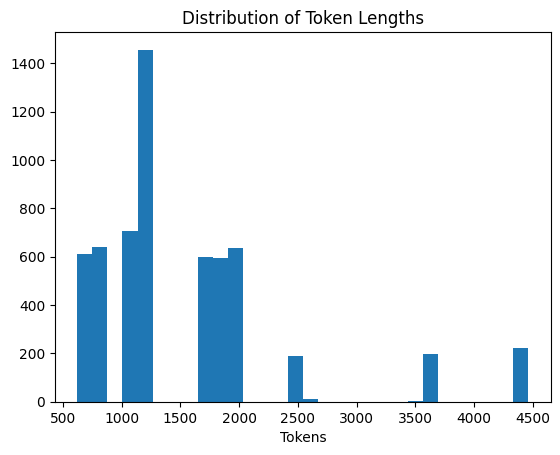

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate length for every example
# We only need the 'input_ids' list to count tokens
token_counts = [len(tokenizer.encode(row["text"])) for row in dataset]

# 2. Print Statistics
print(f"Shortest function: {min(token_counts)} tokens")
print(f"Longest function:  {max(token_counts)} tokens")
print(f"Average length:    {np.mean(token_counts):.1f} tokens")

# 3. (Optional) Visual Check
# If most data is small (<500) but you set max_len=2048, use packing=True!
plt.hist(token_counts, bins=30)
plt.title("Distribution of Token Lengths")
plt.xlabel("Tokens")
plt.show()

In [12]:
# define the config
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj",], #where to add adaptors
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)



In [13]:
import os
os.environ["WANDB_DISABLED"] = "true"

TRL stands for Transformer Reinforcement Learning.

It is a specialized library built by Hugging Face designed to handle the post-training phase of Large Language Models. While the transformers library is for loading and running models, trl is specifically for teaching them how to follow instructions or behave correctly.

In [14]:
from trl import SFTTrainer, SFTConfig

model.config.use_cache = False
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.eos_token_id

sft_config = SFTConfig(
    dataset_text_field="text",   
    packing=False,
    output_dir="./results",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    num_train_epochs=1,
    fp16=True,
    gradient_checkpointing=True,
    save_strategy="epoch",
)

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    peft_config=peft_config,
    args=sft_config,            # <-- tokenizer is NOT passed
)



Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [15]:
peft_model = get_peft_model(model, peft_config)
peft_model.print_trainable_parameters()


trainable params: 7,864,320 || all params: 6,918,230,016 || trainable%: 0.1137


/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:73: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:196: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [16]:
# train model
model.config.use_cache = False  # silence the warnings. Please re-enable for inference!
trainer.train()

# renable warnings
model.config.use_cache = True

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 100001}.


Step,Training Loss
10,0.482500
20,0.221700
30,0.092200
40,0.042500
50,0.023500
60,0.017100
70,0.014300
80,0.013200
90,0.010800
100,0.008300


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [17]:
trainer.save_model("/kaggle/working/final_model")
tokenizer.save_pretrained("/kaggle/working/final_model")


('/kaggle/working/final_model/tokenizer_config.json',
 '/kaggle/working/final_model/special_tokens_map.json',
 '/kaggle/working/final_model/chat_template.jinja',
 '/kaggle/working/final_model/tokenizer.json')

### Push model to hub

In [19]:
from huggingface_hub import notebook_login
notebook_login()

# # option 2: key login
# from huggingface_hub import login
# write_key = 'hf_' # paste token here
# login(write_key)

In [20]:
repo_id = "FatmaElsharkawy/deepseek-lora-sft-assembly2C"
trainer.model.push_to_hub(repo_id)
tokenizer.push_to_hub(repo_id)


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/FatmaElsharkawy/deepseek-lora-sft-assembly2C/commit/9a43d861acef7485c59a3e5290a560993675a8e3', commit_message='Upload tokenizer', commit_description='', oid='9a43d861acef7485c59a3e5290a560993675a8e3', pr_url=None, repo_url=RepoUrl('https://huggingface.co/FatmaElsharkawy/deepseek-lora-sft-assembly2C', endpoint='https://huggingface.co', repo_type='model', repo_id='FatmaElsharkawy/deepseek-lora-sft-assembly2C'), pr_revision=None, pr_num=None)

In [ ]:
model.push_to_hub(model_id)
trainer.push_to_hub(model_id)